<a href="https://colab.research.google.com/github/aullsyifaaa/manipulasi-citra-digital/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

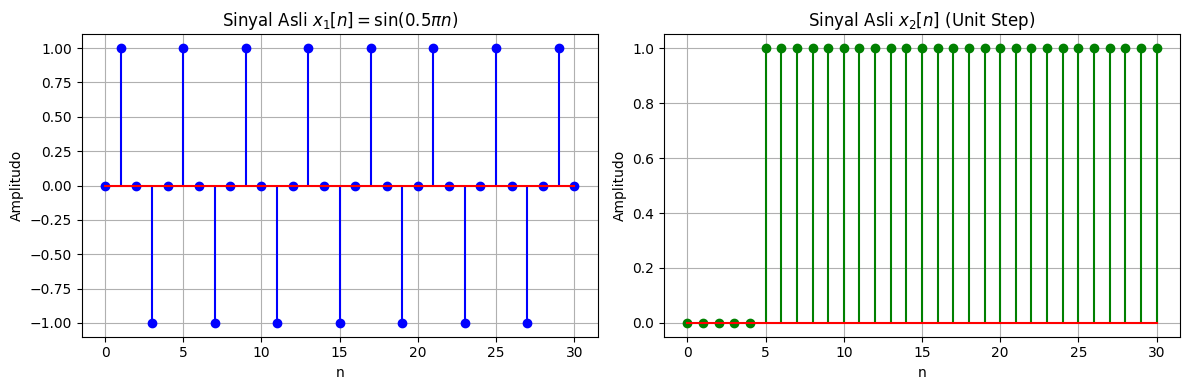

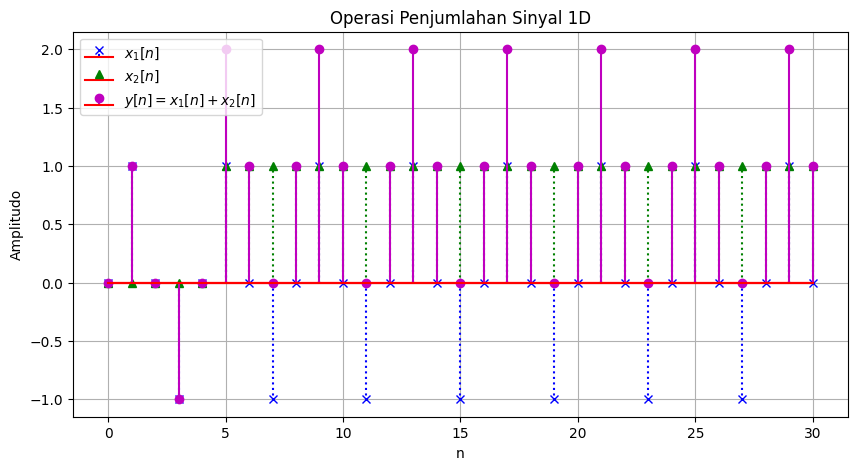

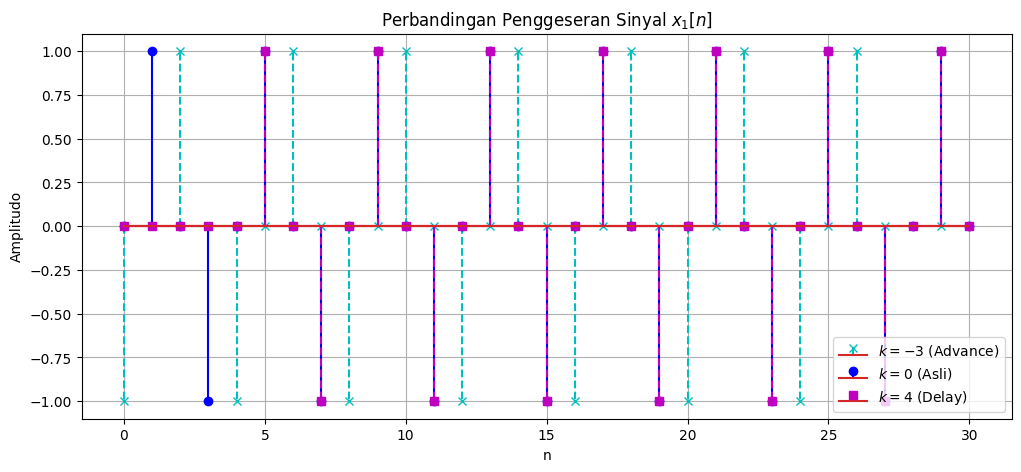

/tmp/ipykernel_1184/3682375865.py:74: UserWarning: Glyph 7 () missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


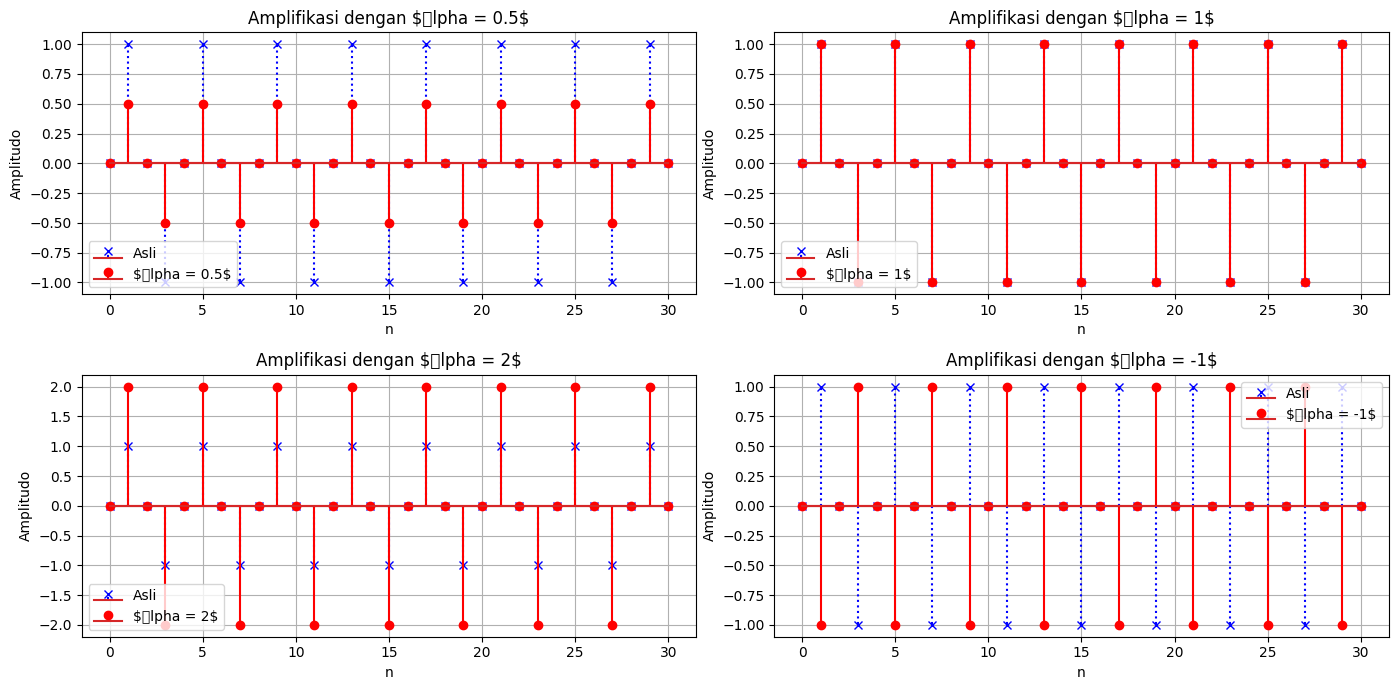

File gambar tidak ditemukan, menggunakan citra buatan (dummy) untuk demo...
Ukuran Citra 1: (300, 300, 3) | Tipe Data: uint8
Nilai Pixel - Min: 0, Max: 254


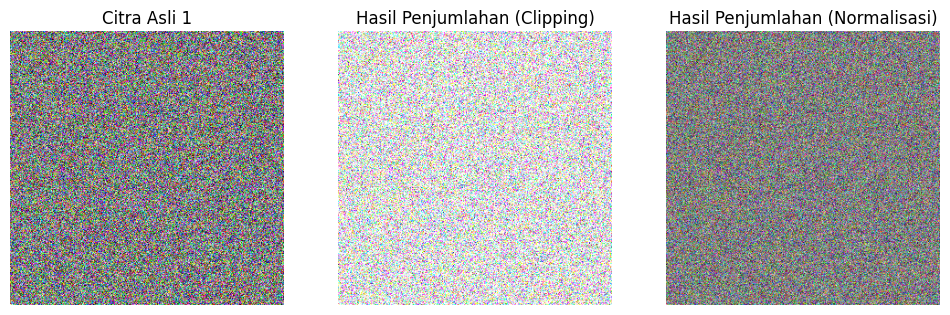

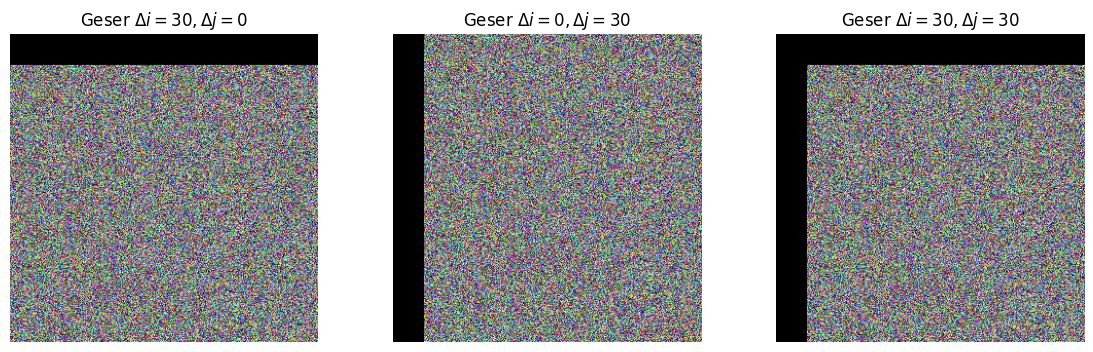

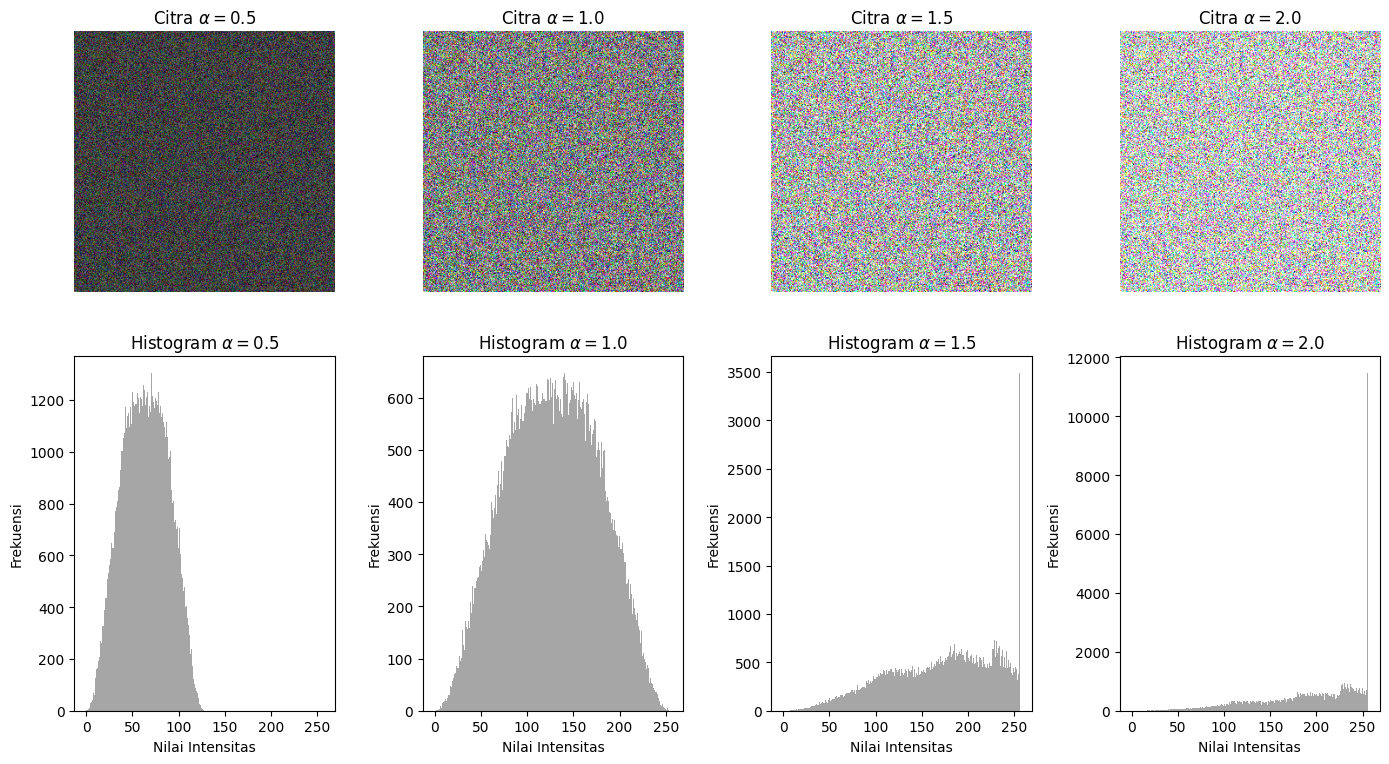

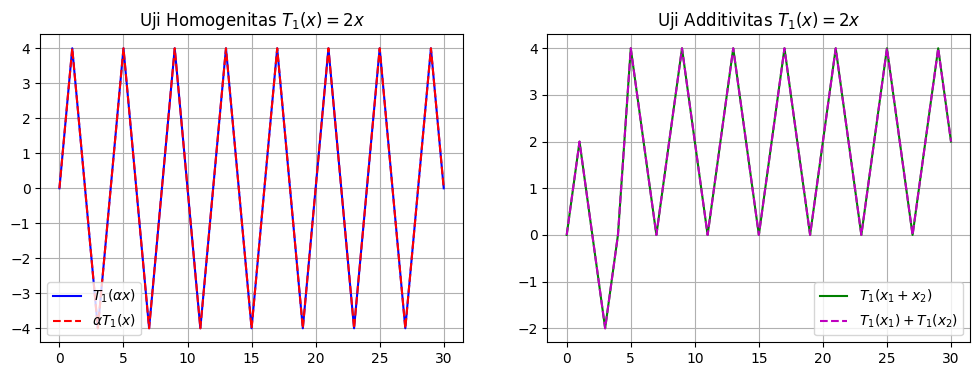

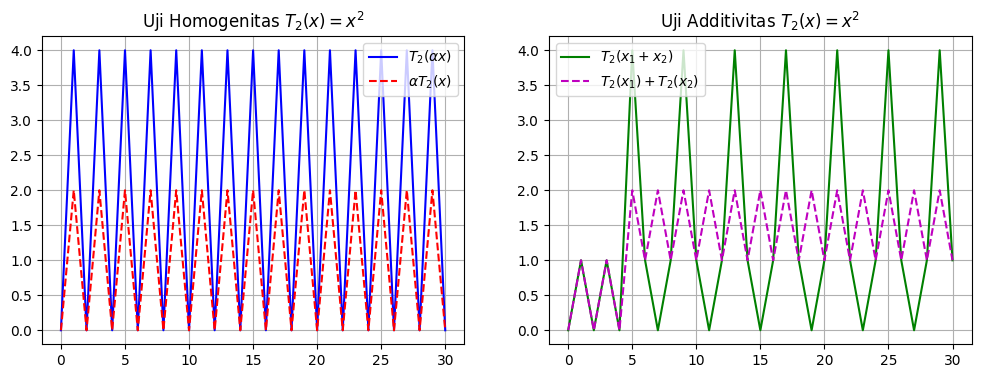

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(0, 31)
x1 = np.sin(0.5 * np.pi * n)
x2 = np.where(n >= 5, 1, 0)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title(r'Sinyal Asli $x_1[n] = \sin(0.5\pi n)$')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Sinyal Asli $x_2[n]$ (Unit Step)')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)
plt.tight_layout()
plt.show()

y_add = x1 + x2

plt.figure(figsize=(10, 5))
plt.stem(n, x1, linefmt='b:', markerfmt='bx', basefmt='r-', label='$x_1[n]$')
plt.stem(n, x2, linefmt='g:', markerfmt='g^', basefmt='r-', label='$x_2[n]$')
plt.stem(n, y_add, linefmt='m-', markerfmt='mo', basefmt='r-', label='$y[n] = x_1[n] + x_2[n]$')
plt.title('Operasi Penjumlahan Sinyal 1D')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.legend()
plt.grid(True)
plt.show()

def shift_signal(x, n, k):
    y = np.zeros_like(x)
    for i in range(len(n)):
        shifted_index = n[i] - k
        if shifted_index in n:
            y[i] = x[np.where(n == shifted_index)[0][0]]
    return y

y_shift_neg = shift_signal(x1, n, -3)
y_shift_zero = shift_signal(x1, n, 0)
y_shift_pos = shift_signal(x1, n, 4)

plt.figure(figsize=(12, 5))
plt.stem(n, y_shift_neg, linefmt='c--', markerfmt='cx', label='$k = -3$ (Advance)')
plt.stem(n, y_shift_zero, linefmt='b-', markerfmt='bo', label='$k = 0$ (Asli)')
plt.stem(n, y_shift_pos, linefmt='m--', markerfmt='ms', label='$k = 4$ (Delay)')
plt.title('Perbandingan Penggeseran Sinyal $x_1[n]$')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.legend()
plt.grid(True)
plt.show()

alphas = [0.5, 1, 2, -1]
plt.figure(figsize=(14, 7))
for i, alpha in enumerate(alphas):
    y_amp = alpha * x1
    plt.subplot(2, 2, i+1)
    plt.stem(n, x1, linefmt='b:', markerfmt='bx', label='Asli')
    plt.stem(n, y_amp, linefmt='r-', markerfmt='ro', label=f'\\$\alpha = {alpha}$')
    plt.title(f'Amplifikasi dengan \\$\alpha = {alpha}$')
    plt.xlabel('n')
    plt.ylabel('Amplitudo')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

try:
    img1 = cv2.imread('pantai.jpg')
    img2 = cv2.imread('kucing.jpg')

    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
except Exception as e:
    print("File gambar tidak ditemukan, menggunakan citra buatan (dummy) untuk demo...")
    img1 = np.uint8(np.random.rand(300, 300, 3) * 255)
    img2 = np.uint8(np.random.rand(300, 300, 3) * 255)

if img1.shape != img2.shape:
    print(f"Ukuran berbeda! Resizing img2 dari {img2.shape[:2]} ke {img1.shape[:2]}")
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

print(f"Ukuran Citra 1: {img1.shape} | Tipe Data: {img1.dtype}")
print(f"Nilai Pixel - Min: {img1.min()}, Max: {img1.max()}")

img_add_clip = cv2.add(img1, img2)

img_add_norm = img1.astype(np.float32) + img2.astype(np.float32)
img_add_norm = cv2.normalize(img_add_norm, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img1)
plt.title('Citra Asli 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_add_clip)
plt.title('Hasil Penjumlahan (Clipping)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_add_norm)
plt.title('Hasil Penjumlahan (Normalisasi)')
plt.axis('off')
plt.show()

rows, cols, _ = img1.shape
shifts = [(30, 0), (0, 30), (30, 30)]

plt.figure(figsize=(14, 4))
for i, (di, dj) in enumerate(shifts):

    M = np.float32([[1, 0, dj], [0, 1, di]])
    img_shifted = cv2.warpAffine(img1, M, (cols, rows))

    plt.subplot(1, 3, i+1)
    plt.imshow(img_shifted)
    plt.title(f'Geser $\\Delta i={di}, \\Delta j={dj}$')
    plt.axis('off')
plt.show()

alphas_img = [0.5, 1.0, 1.5, 2.0]
plt.figure(figsize=(14, 8))

for i, alpha in enumerate(alphas_img):
    img_amp = cv2.convertScaleAbs(img1, alpha=alpha, beta=0)

    plt.subplot(2, 4, i+1)
    plt.imshow(img_amp)
    plt.title(f'Citra $\\alpha = {alpha}$')
    plt.axis('off')

    gray_amp = cv2.cvtColor(img_amp, cv2.COLOR_RGB2GRAY)
    plt.subplot(2, 4, i+5)
    plt.hist(gray_amp.ravel(), bins=256, range=[0,256], color='gray', alpha=0.7)
    plt.title(f'Histogram $\\alpha = {alpha}$')
    plt.xlabel('Nilai Intensitas')
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

def T1(x): return 2 * x
def T2(x): return x ** 2

a = 2  # Define 'a' here

homo_left_t1 = T1(a * x1)
homo_right_t1 = a * T1(x1)
add_left_t1 = T1(x1 + x2)
add_right_t1 = T1(x1) + T2(x2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(n, homo_left_t1, 'b-', label=r'$T_1(\alpha x)$')
plt.plot(n, homo_right_t1, 'r--', label=r'$\alpha T_1(x)$')
plt.title('Uji Homogenitas $T_1(x) = 2x$')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n, T1(x1 + x2), 'g-', label='$T_1(x_1 + x_2)$')
plt.plot(n, T1(x1) + T1(x2), 'm--', label='$T_1(x_1) + T_1(x_2)$')
plt.title('Uji Additivitas $T_1(x) = 2x$')
plt.legend()
plt.grid(True)
plt.show()

homo_left_t2 = T2(a * x1)
homo_right_t2 = a * T2(x1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(n, homo_left_t2, 'b-', label=r'$T_2(\alpha x)$')
plt.plot(n, homo_right_t2, 'r--', label=r'$\alpha T_2(x)$')
plt.title('Uji Homogenitas $T_2(x) = x^2$')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n, T2(x1 + x2), 'g-', label='$T_2(x_1 + x_2)$')
plt.plot(n, T2(x1) + T2(x2), 'm--', label='$T_2(x_1) + T_2(x_2)$')
plt.title('Uji Additivitas $T_2(x) = x^2$')
plt.legend()
plt.grid(True)
plt.show()

# Manipulasi Citra Digital Menggunakan OpenCV

[cite_start]Project ini dibuat untuk memenuhi Tugas Individu mata kuliah **Pengolahan Sinyal Digital**[cite: 1, 3]. [cite_start]Di dalam project ini, dilakukan serangkaian eksperimen manipulasi dasar citra digital menggunakan bahasa pemrograman Python dan beberapa library populer seperti OpenCV, NumPy, dan Matplotlib[cite: 5, 33].

## 👤 Identitas Mahasiswa
* **Nama:** Syifa Aulia Khairunnisa
* [cite_start]**Mata Kuliah:** Pengolahan Sinyal Digital [cite: 3]
* [cite_start]**Topik Tugas:** Manipulasi Citra Digital [cite: 2]

---

## 📝 Deskripsi Singkat Project
[cite_start]Project ini berfokus pada implementasi operasi matematika sederhana pada tingkat pixel citra dan analisis dampaknya terhadap kualitas visual, nilai pixel, kecerahan (*brightness*), kontras (*contrast*), serta detail citra[cite: 16, 18]. Eksperimen yang dilakukan meliputi:
1. [cite_start]Membaca citra asli dan konversi warna dari format BGR ke RGB[cite: 6, 7].
2. [cite_start]Mengubah ukuran (*resize*) dua citra berbeda agar memiliki dimensi yang sama[cite: 8, 23, 68].
3. [cite_start]Penggabungan dua citra (*image blending*) dengan variasi kombinasi bobot[cite: 9, 24, 96].
4. [cite_start]Pembuatan citra negatif beserta analisis histogramnya[cite: 10, 25, 124, 125].
5. [cite_start]Penerapan transformasi non-linier Logaritmik[cite: 11, 26].
6. [cite_start]Penerapan transformasi non-linier Gamma (Power-Law)[cite: 12, 27].

---

## 🖼️ Citra yang Digunakan
[cite_start]Project ini menggunakan minimal dua citra berbeda dengan karakteristik spasial yang berlainan[cite: 17, 44]:
* [cite_start]`image1.jpg`: Digunakan sebagai citra utama dalam eksperimen transformasi spasial (Negative, Log, Gamma)[cite: 120, 144, 168].
* [cite_start]`image2.jpg`: Digunakan sebagai citra tekstur/komplemen untuk proses blending[cite: 94].

---

## 🛠️ Library yang Digunakan
[cite_start]Pastikan library berikut sudah terinstall di dalam environment Python Anda[cite: 33]:
* [cite_start]**OpenCV (opencv-python):** Untuk operasi I/O citra, konversi warna, resize, dan blending[cite: 34].
* [cite_start]**NumPy:** Untuk manipulasi array matriks pixel dan operasi matematika logaritmik/gamma[cite: 35].
* [cite_start]**Matplotlib:** Untuk visualisasi citra luaran dan plotting histogram[cite: 36].

---

## 📂 Struktur Folder Project
[cite_start]Repositori GitHub ini diatur dengan struktur minimal sebagai berikut[cite: 252, 253]:

```text
manipulasi-citra-digital/
├── notebook/
│   └── image_manipulation.ipynb   # File notebook utama eksperimen
├── images/
│   ├── image1.jpg                  # Citra sampel 1
│   └── image2.jpg                  # Citra sampel 2
└── report/
    ├── laporan.pdf                 # Laporan resmi hasil analisis
    ├── README.md                   # Dokumentasi project
    └── requirements.txt            # Daftar dependensi library